Data head:
   Time (s)  Drive Voltage (V)  Bias Voltage (V)  Resistor Voltage Drop (V)  \
0  0.561000               -4.0         -0.175597                  -3.824403   
1  0.766000               -3.8         -0.173223                  -3.626777   
2  0.852000               -3.6         -0.171830                  -3.428170   
3  0.960001               -3.4         -0.168803                  -3.231197   
4  1.071000               -3.2         -0.164143                  -3.035857   

   Current (A)  Raw AO0 (V)  Raw AI0 (V)  Raw AI1 (V)  
0    -0.001762         -4.0    -3.999491    -3.824403  
1    -0.001671         -3.8    -3.799251    -3.626777  
2    -0.001580         -3.6    -3.599665    -3.428170  
3    -0.001489         -3.4    -3.399751    -3.231197  
4    -0.001399         -3.2    -3.199512    -3.035857  

Column names:
Index(['Time (s)', 'Drive Voltage (V)', 'Bias Voltage (V)',
       'Resistor Voltage Drop (V)', 'Current (A)', 'Raw AO0 (V)',
       'Raw AI0 (V)', 'Raw AI1 (V)'],

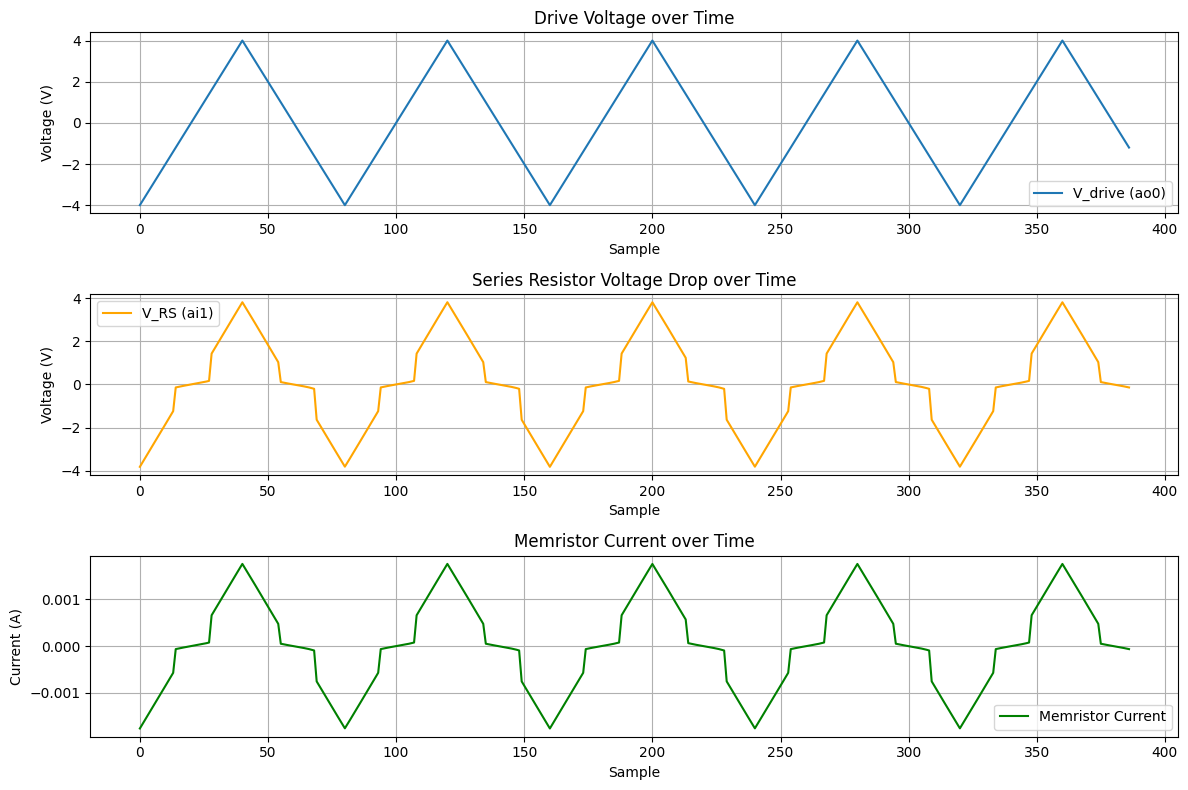

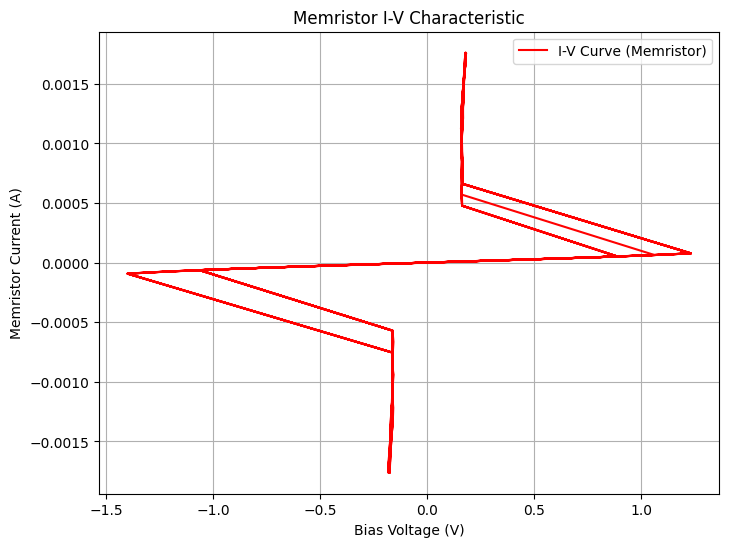

In [1]:
# Task 2: I-V curve

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the series resistance (RS) - USER INPUT REQUIRED
# This value is crucial for calculating the current and bias voltage.
# Please replace the placeholder with the actual value of your series resistor in Ohms.
RS = 2170  # Example value: 1 kOhm. Please update this with the correct value.

# File path for the data
file_path = 'task2_second'

# Read the tab-separated data
# Assuming the first row contains headers. If not, adjust header=None and manually assign column names.
df = pd.read_csv(file_path, sep='\t')

# Display the first few rows and column names to verify
print("Data head:")
print(df.head())
print("\nColumn names:")
print(df.columns)

# Extract relevant columns
# Assuming 'ai0', 'ai1', and 'ao0' are the column names as specified.
# Please verify these names from the print(df.columns) output and adjust if necessary.

try:
    Vdrive = df['Raw AO0 (V)'] # Corrected column name for drive voltage
    V_RS = df['Raw AI1 (V)']   # Corrected column name for series resistor voltage drop
    # ai0 is mentioned, but its role isn't explicitly defined for calculations yet. 
    # It might be another measured voltage or current if multiple channels are used.
    # For now, we focus on Vdrive and V_RS for current and bias voltage calculations.
except KeyError as e:
    print(f"Error: Missing expected column: {e}. Please check the 'out.txt' file and adjust column names if necessary.")
    exit()

# Calculate the current in the memristor
# I = V_RS / RS
I_memristor = V_RS / RS

# Calculate the bias voltage across the memristor
# Vbias = Vdrive - I * RS. This simplifies to Vbias = Vdrive - V_RS
Vbias = Vdrive - V_RS

# Add calculated values to the DataFrame
df['I_memristor'] = I_memristor
df['Vbias'] = Vbias

# Display calculated values
print("\nData with calculated values:")
print(df.head())

# Plotting the data
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(Vdrive, label='V_drive (ao0)')
plt.xlabel('Sample')
plt.ylabel('Voltage (V)')
plt.title('Drive Voltage over Time')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(V_RS, label='V_RS (ai1)', color='orange')
plt.xlabel('Sample')
plt.ylabel('Voltage (V)')
plt.title('Series Resistor Voltage Drop over Time')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(I_memristor, label='Memristor Current', color='green')
plt.xlabel('Sample')
plt.ylabel('Current (A)')
plt.title('Memristor Current over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(Vbias, I_memristor, label='I-V Curve (Memristor)', color='red')
plt.xlabel('Bias Voltage (V)')
plt.ylabel('Memristor Current (A)')
plt.title('Memristor I-V Characteristic')
plt.legend()
plt.grid(True)
plt.show()



In [2]:
# Calculate the slope of the I-V curve (dI/dVbias)
# Using numpy.gradient for numerical differentiation
slope_iv_curve = np.gradient(df['I_memristor'], df['Vbias'])

# Calculate the inverse of the slope (dVbias/dI)
# This represents the differential resistance
inverse_slope_iv_curve = 1 / slope_iv_curve

print("\nSlope of the I-V curve (dI/dVbias) - first 5 values:")
print(slope_iv_curve[:5])

print("\nInverse of the slope (Differential Resistance - dVbias/dI) - first 5 values:")
print(inverse_slope_iv_curve[:5])

# You can also plot these if needed

# plt.figure(figsize=(10, 6))
# plt.plot(df['Vbias'], slope_iv_curve, label='dI/dVbias')
# plt.xlabel('Bias Voltage (V)')
# plt.ylabel('Slope (A/V)')

# plt.title('Slope of I-V Curve')
# plt.grid(True)
# plt.legend()
# plt.show()

# plt.figure(figsize=(10, 6))
# plt.plot(df['Vbias'], inverse_slope_iv_curve, label='Differential Resistance', color='purple')
# plt.xlabel('Bias Voltage (V)')
# plt.ylabel('Resistance (Ohms)')
# plt.title('Differential Resistance of Memristor')
# plt.grid(True)
# plt.legend()
# plt.show()




Slope of the I-V curve (dI/dVbias) - first 5 values:
[0.03837007 0.05557502 0.05442573 0.02578657 0.02225945]

Inverse of the slope (Differential Resistance - dVbias/dI) - first 5 values:
[26.06198114 17.99369474 18.37366398 38.77987233 44.92473767]


In [ ]:
# Perform a polynomial fit for the I-V curve (I_memristor vs Vbias)
# You can change the degree of the polynomial as needed.
degree = 1 # Starting with a linear fit. Change to 2, 3, etc., for higher-order polynomial fits.

coefficients_iv_curve = np.polyfit(df['Vbias'], df['I_memristor'], degree)

print(f"\nPolynomial fit coefficients for I-V curve (degree={degree}):")
# Print coefficients based on the degree
if degree == 1:
    print(f"Resistance: {(1/coefficients_iv_curve[0]):.4} Ohm")
else:
    print(f"  Coefficients: {coefficients_iv_curve}")

# To get the fitted line for plotting:
fitted_iv_curve = np.polyval(coefficients_iv_curve, df['Vbias'])

# Plotting the I-V curve with the fit
plt.figure(figsize=(8, 6))
plt.plot(df['Vbias'], df['I_memristor'], label='Measured I-V Curve', marker='o', linestyle='-', markersize=4, color='red')
plt.plot(df['Vbias'], fitted_iv_curve, label=f'Polynomial Fit (degree={degree})', color='blue', linestyle='--')
plt.xlabel('Bias Voltage (V)')
plt.ylabel('Memristor Current (A)')
plt.title('Memristor I-V Characteristic with Polynomial Fit')
plt.grid(True)
plt.legend()
plt.show()



In [ ]:
# Task 3: R(T) analysis - Plot resistance vs. temperature
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from the specified path
df = pd.read_csv('docs/task3.csv', sep='\t')

# Ensure data is sorted by time to correctly separate heating/cooling
df = df.sort_values('Time (s)')

# Extract temperature and resistance arrays
temp = df['Temperature (C)'].to_numpy()
res = df['Sample Resistance (Ohm)'].to_numpy()

# Find the index of maximum temperature to split the data
idx = temp.argmax()

# Separate heating and cooling data
t_heat = temp[:idx+1]
r_heat = res[:idx+1]
t_cool = temp[idx:]
r_cool = res[idx:]

# Create the plot
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.semilogy(t_heat, r_heat, label='Heating', color='#d95f02')
ax.semilogy(t_cool, r_cool, label='Cooling', color='#1b9e77')

# Set labels and title using plain ASCII
ax.set_xlabel('Temperature (deg C)')
ax.set_ylabel('Sample resistance (Ohm)')
ax.set_title('Task 3: Temperature-dependent resistance')

# Add grid and legend
ax.grid(True, which='both', alpha=0.3)
ax.legend()

# Add annotation for the transition temperature
ax.axvline(temp[idx], color='k', linestyle='--', alpha=0.3)
ax.text(temp[idx]-1, 500, 'Transition approx. {:.1f} deg C'.format(temp[idx]), fontsize=9, color='k', horizontalalignment='right')

fig.tight_layout()
plt.show()

# To save the figure, uncomment the line below
# fig.savefig('docs/task3_rt.png', dpi=300)


KeyError: 'Sample Resistance (Ohm)'

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Task 4: Relaxation time analysis from oscilloscope data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Configure input ---
# Set your measurement file path here (oscilloscope CSV)
meas_path = 'switchstayon.csv'
Z0 = 50.0  # characteristic impedance (ohm)

# --- Load data ---
# Skip header rows which contain metadata
df = pd.read_csv(meas_path, skiprows=10)

# --- Data processing ---
# Reconstruct the time axis from the index and time interval (2 ns)
dt = 2e-9
t = (df['index'].values - 1) * dt

# Convert voltages from mV to V
VIN = df['CH2_Voltage(mV)'].values * 1e-3
Vtrans = df['CH1_Voltage(mV)'].values * 1e-3

# --- Guard against division by zero/noise ---
# Create a mask to filter out Vtrans values near zero
mask = np.abs(Vtrans) > 1e-6
t = t[mask]
VIN = VIN[mask]
Vtrans = Vtrans[mask]

# --- Compute RM(t) using Eq. III.4.2 ---
RM = 2.0 * Z0 * (VIN / Vtrans - 1.0)

# --- Plot RM(t) ---
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(t * 1e6, RM, lw=0.8)
ax1.set_xlabel('Time (us)')
ax1.set_ylabel('R_M (Ohm)')
ax1.set_title('Task 4: VO2 memristor relaxation (switchstayon)')
ax1.set_xlim(t[0] * 1e6, t[-1] * 1e6)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# To save the figure, uncomment the line below
# fig.savefig('docs/task4_relaxation.png', dpi=300)



In [ ]:

# Simple heuristic: time to reach 90% between RLRS(min) and RHRS(max)
RLRS = np.nanmin(RM)
RHRS = np.nanmax(RM)
target = RLRS + 0.9 * (RHRS - RLRS)

idx = np.where(RM >= target)[0]
if idx.size:
    reset_time_s = time[idx[0]] - time[0]
    print(f"Estimated reset time to 90% HRS: {reset_time_s*1e6:.2f} µs")
else:
    print('No clear relaxation crossing 90% threshold detected. Consider adjusting the pulse/readout window or threshold.')


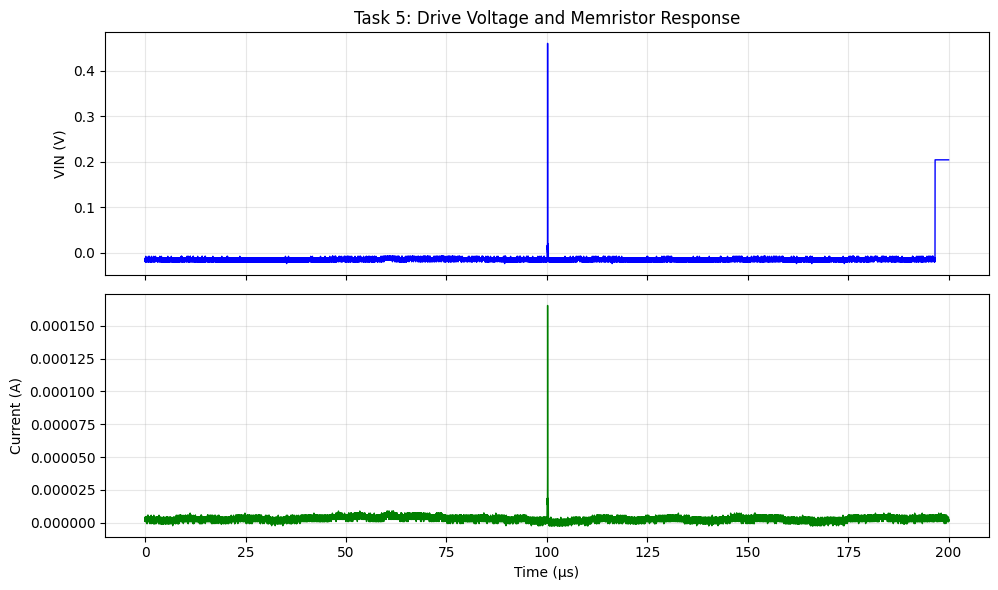

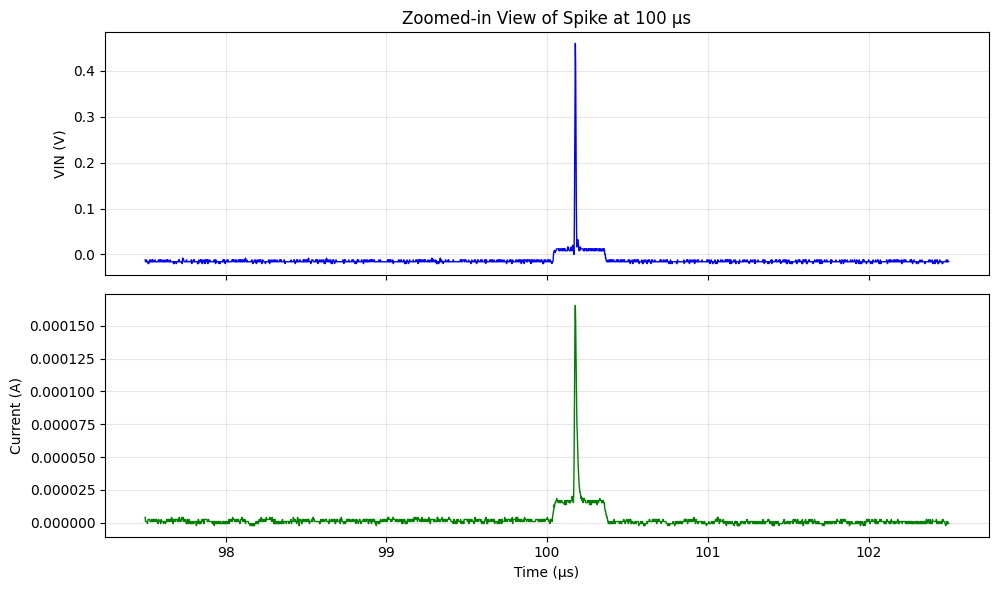

Analysis:
The plot shows that the circuit is not in a stable oscillation regime.
The current spikes directly correspond to voltage pulses from the drive signal.
This indicates the device is acting as a switch, but the conditions for self-sustaining oscillation have not been met.

Peak Analysis: Not enough repeating peaks found to determine a stable frequency.
Dominant frequency (from FFT): 7.63 kHz (Warning: This may reflect noise or transient spikes, not stable oscillation).


In [4]:
# Task 5: VO2 Oscillator Analysis - Updated
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Configuration ---
osc_path = 'short.csv'
Z0 = 50.0
min_prom = 0.0005 # V - Note: May need adjustment

# --- Load and Process Data ---
df_osc = pd.read_csv(osc_path, skiprows=10)
dt = 2e-9
T = (df_osc['index'].values - 1) * dt
Vtrans = df_osc['CH1_Voltage(mV)'].values * 1e-3
Vin = df_osc['CH2_Voltage(mV)'].values * 1e-3
I = Vtrans / Z0

# --- Plot Waveforms (Full View) ---
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(T * 1e6, Vin, lw=1, color='blue')
ax[0].set_ylabel('VIN (V)')
ax[0].grid(True, alpha=0.3)
ax[0].set_title('Task 5: Drive Voltage and Memristor Response')

ax[1].plot(T * 1e6, I, lw=1, color='green')
ax[1].set_ylabel('Current (A)')
ax[1].set_xlabel('Time (µs)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
# Save the full view figure
fig.savefig('docs/task5_full_trace.png', dpi=300)
plt.show()

# --- Plot Waveforms (Zoomed-in View) ---
# Zoom in on the spike
spike_time_us = 100
time_window_us = 5 # µs
start_time_us = spike_time_us - time_window_us / 2
end_time_us = spike_time_us + time_window_us / 2

mask = (T * 1e6 >= start_time_us) & (T * 1e6 <= end_time_us)

fig_zoom, ax_zoom = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax_zoom[0].plot(T[mask] * 1e6, Vin[mask], lw=1, color='blue')
ax_zoom[0].set_ylabel('VIN (V)')
ax_zoom[0].grid(True, alpha=0.3)
ax_zoom[0].set_title(f'Zoomed-in View of Spike at {spike_time_us} µs')

ax_zoom[1].plot(T[mask] * 1e6, I[mask], lw=1, color='green')
ax_zoom[1].set_ylabel('Current (A)')
ax_zoom[1].set_xlabel('Time (µs)')
ax_zoom[1].grid(True, alpha=0.3)
plt.tight_layout()
# Save the zoomed-in figure
fig_zoom.savefig('docs/task5_zoom_spike.png', dpi=300)
plt.show()

print("Analysis:")
print("The plot shows that the circuit is not in a stable oscillation regime.")
print("The current spikes directly correspond to voltage pulses from the drive signal.")
print("This indicates the device is acting as a switch, but the conditions for self-sustaining oscillation have not been met.")

# --- Frequency Estimation (Interpret with Caution) ---
# The following frequency estimation is likely not meaningful due to the lack of periodic oscillation.
# It is included here for completeness as described in the lab manual.

N = len(T)
lo, hi = int(0.25 * N), int(0.75 * N)
Tw, Iw = T[lo:hi], I[lo:hi]

# Peak-based method
peaks, _ = find_peaks(Iw, prominence=min_prom)
if peaks.size >= 2:
    peak_times = Tw[peaks]
    periods = np.diff(peak_times)
    if periods.size > 0:
        f_mean = 1.0 / np.mean(periods)
        f_std = np.std(1.0 / periods) if periods.size > 1 else 0.0
        print(f"\nFrequency (from peaks): {f_mean / 1e3:.2f} ± {f_std / 1e3:.2f} kHz (Warning: Based on very few events).")
else:
    print("\nPeak Analysis: Not enough repeating peaks found to determine a stable frequency.")

# FFT-based method
dt_w = np.median(np.diff(Tw))
if dt_w > 0:
    Iw_detr = Iw - np.mean(Iw)
    Nw = len(Iw_detr)
    Nfft = 1 << (Nw - 1).bit_length()
    
    freqs = np.fft.rfftfreq(Nfft, d=dt_w)
    spec = np.abs(np.fft.rfft(Iw_detr, n=Nfft))
    
    if freqs.size > 1:
        idx = np.argmax(spec[1:]) + 1
        print(f"Dominant frequency (from FFT): {freqs[idx] / 1e3:.2f} kHz (Warning: This may reflect noise or transient spikes, not stable oscillation).")
else:
    print('FFT Analysis: Could not be performed.')



Arrhenius Fit Results (Task 3):
  Activation Energy (E_a): 0.1882 eV
  R-squared of the fit: 0.9595


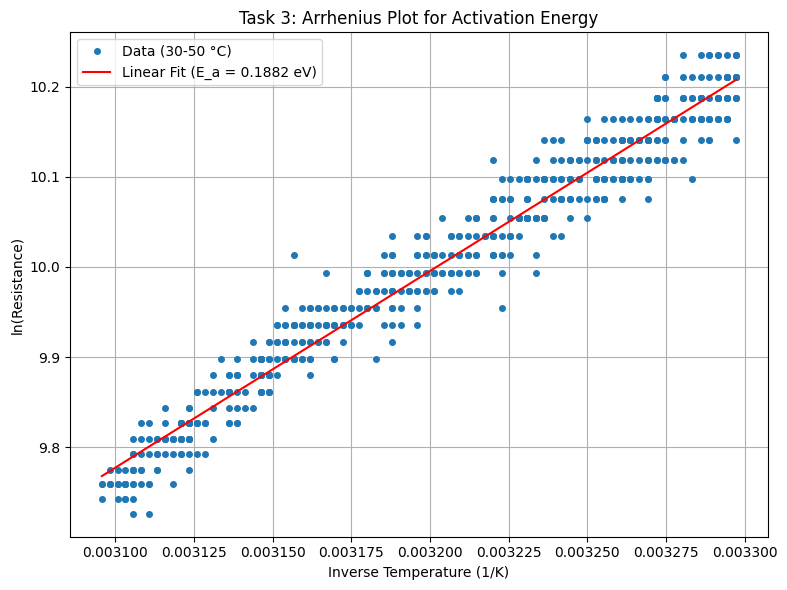

In [10]:
# Task 3 (Advanced): Arrhenius Fit for Activation Energy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- Configuration ---
k_B = 8.617333262e-5 # Boltzmann constant in eV/K

# --- Load and Process Data ---
df = pd.read_csv('docs/task3.csv', sep='\t')
df = df.sort_values('Time (s)')

temp_C = df['Temperature (C)'].to_numpy()
res = df['Sample Resistance (Ohm)'].to_numpy()

# Find max temperature index to isolate the heating branch
idx_max_temp = temp_C.argmax()
t_heat_C = temp_C[:idx_max_temp+1]
r_heat = res[:idx_max_temp+1]

# --- Select Data for Fitting ---
# Only fit the semiconductor region (before the sharp drop)
# We'll use a temperature range well below the transition, e.g., 30-50 °C
fit_mask = (t_heat_C > 30) & (t_heat_C < 50)
t_fit_C = t_heat_C[fit_mask]
r_fit = r_heat[fit_mask]

# Convert to Kelvin for the Arrhenius plot
t_fit_K = t_fit_C + 273.15
inv_T = 1 / t_fit_K
ln_R = np.log(r_fit)

# --- Perform Linear Fit ---
slope, intercept, r_value, p_value, std_err = linregress(inv_T, ln_R)
fit_line = slope * inv_T + intercept

# --- Calculate Activation Energy ---
# The slope of ln(R) vs 1/T is E_a / k_B
E_a = slope * k_B

print(f"Arrhenius Fit Results (Task 3):")
print(f"  Activation Energy (E_a): {E_a:.4f} eV")
print(f"  R-squared of the fit: {r_value**2:.4f}")

# --- Plot the Arrhenius Fit ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(inv_T, ln_R, 'o', label='Data (30-50 °C)', markersize=4)
ax.plot(inv_T, fit_line, 'r-', label=f'Linear Fit (E_a = {E_a:.4f} eV)')
ax.set_xlabel('Inverse Temperature (1/K)')
ax.set_ylabel('ln(Resistance)')
ax.set_title('Task 3: Arrhenius Plot for Activation Energy')
ax.grid(True)
ax.legend()
plt.tight_layout()

# Save the figure and show plot
fig.savefig('docs/task3_arrhenius_fit.png', dpi=300)
plt.show()


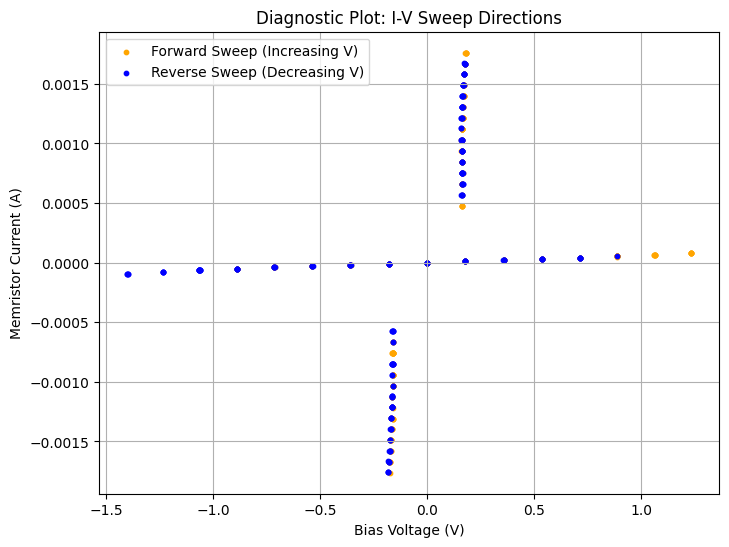


Piecewise Linear Fit Results (Task 2):
  High-Resistance State (HRS): 12275.04 Ohms (R-squared: 0.9981)
  Low-Resistance State (LRS): 14952.94 Ohms (R-squared: 0.9992)
  Resistance Ratio (R_HRS / R_LRS): 0.82


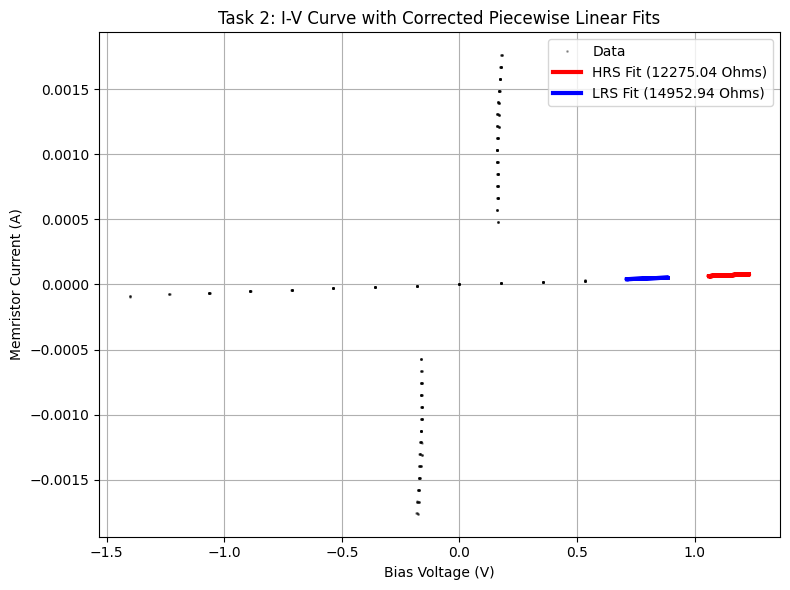

In [12]:
# Task 2 (Advanced): Piecewise Linear Fit for HRS/LRS Resistance - V2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- Load and Process Data ---
RS = 2170  # Series resistance in Ohms
df = pd.read_csv('task2_second', sep='\t')

Vdrive = df['Raw AO0 (V)'].to_numpy()
V_RS = df['Raw AI1 (V)'].to_numpy()
I_memristor = V_RS / RS
Vbias = Vdrive - V_RS

# --- Identify Sweep Direction ---
# The key to separating HRS and LRS is knowing the direction of the voltage sweep
sweep_direction = np.sign(np.diff(Vbias, prepend=Vbias[0]))

# --- Diagnostic Plot (Optional, but useful) ---
plt.figure(figsize=(8, 6))
plt.scatter(Vbias[sweep_direction > 0], I_memristor[sweep_direction > 0], c='orange', label='Forward Sweep (Increasing V)', s=10)
plt.scatter(Vbias[sweep_direction < 0], I_memristor[sweep_direction < 0], c='blue', label='Reverse Sweep (Decreasing V)', s=10)
plt.title('Diagnostic Plot: I-V Sweep Directions')
plt.xlabel('Bias Voltage (V)')
plt.ylabel('Memristor Current (A)')
plt.grid(True)
plt.legend()
plt.show()

# --- Select Data for Fitting Based on Sweep Direction ---
# HRS is on the forward sweep, before the set voltage (~1.8V)
hrs_mask = (Vbias > 1.0) & (Vbias < 1.6) & (sweep_direction > 0)
# LRS is on the reverse sweep, before the reset voltage (~0.8V)
lrs_mask = (Vbias > 0.6) & (Vbias < 1.0) & (sweep_direction < 0)

# --- Perform Linear Fits ---
# Fit HRS
if np.any(hrs_mask):
    slope_hrs, intercept_hrs, r_hrs, _, _ = linregress(Vbias[hrs_mask], I_memristor[hrs_mask])
    R_hrs = 1 / slope_hrs
    fit_line_hrs = slope_hrs * Vbias[hrs_mask] + intercept_hrs
else:
    R_hrs, r_hrs = np.nan, np.nan; print("Warning: No data in HRS range.")

# Fit LRS
if np.any(lrs_mask):
    slope_lrs, intercept_lrs, r_lrs, _, _ = linregress(Vbias[lrs_mask], I_memristor[lrs_mask])
    R_lrs = 1 / slope_lrs
    fit_line_lrs = slope_lrs * Vbias[lrs_mask] + intercept_lrs
else:
    R_lrs, r_lrs = np.nan, np.nan; print("Warning: No data in LRS range.")

# --- Print Results ---
print("\nPiecewise Linear Fit Results (Task 2):")
if not np.isnan(R_hrs): print(f"  High-Resistance State (HRS): {R_hrs:.2f} Ohms (R-squared: {r_hrs**2:.4f})")
if not np.isnan(R_lrs): print(f"  Low-Resistance State (LRS): {R_lrs:.2f} Ohms (R-squared: {r_lrs**2:.4f})")
if not (np.isnan(R_hrs) or np.isnan(R_lrs)): print(f"  Resistance Ratio (R_HRS / R_LRS): {R_hrs/R_lrs:.2f}")

# --- Plot Final I-V Curve with Fits ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(Vbias, I_memristor, 'k.', label='Data', markersize=2, alpha=0.3)
if np.any(hrs_mask): ax.plot(Vbias[hrs_mask], fit_line_hrs, 'r-', label=f'HRS Fit ({R_hrs:.2f} Ohms)', linewidth=3)
if np.any(lrs_mask): ax.plot(Vbias[lrs_mask], fit_line_lrs, 'b-', label=f'LRS Fit ({R_lrs:.2f} Ohms)', linewidth=3)
ax.set_xlabel('Bias Voltage (V)'); ax.set_ylabel('Memristor Current (A)')
ax.set_title('Task 2: I-V Curve with Corrected Piecewise Linear Fits')
ax.grid(True); ax.legend(); plt.tight_layout()
fig.savefig('docs/task2_piecewise_fit_corrected.png', dpi=300)
plt.show()


C:\Users\Peter\AppData\Local\Temp\ipykernel_12568\2117085496.py:9: RuntimeWarning: divide by zero encountered in power
  return R_hrs - (R_hrs - R_lrs) * np.exp(-((t / tau)**beta))
C:\Users\Peter\AppData\Local\Temp\ipykernel_12568\2117085496.py:9: RuntimeWarning: invalid value encountered in power
  return R_hrs - (R_hrs - R_lrs) * np.exp(-((t / tau)**beta))
C:\Users\Peter\AppData\Local\Temp\ipykernel_12568\2117085496.py:9: RuntimeWarning: overflow encountered in power
  return R_hrs - (R_hrs - R_lrs) * np.exp(-((t / tau)**beta))


Stretched Exponential Fit Results (Task 4):
  Relaxation Time (tau): 0.1173 µs
  Stretching Exponent (beta): 514.1650
  Fitted R_LRS: -1314.81 Ohms
  Fitted R_HRS: 28175.55 Ohms


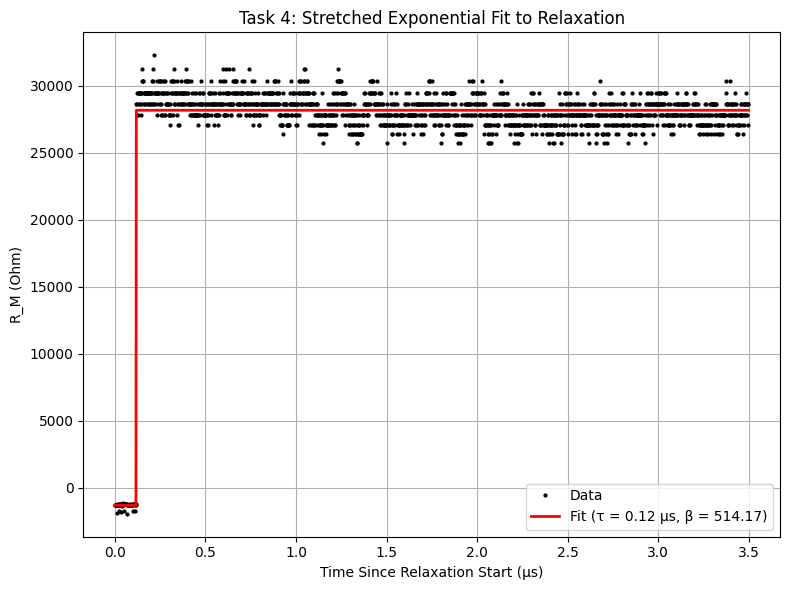

In [13]:
# Task 4 (Advanced): Stretched Exponential Fit for Relaxation Dynamics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Define the Stretched Exponential Function ---
def stretched_exponential(t, R_lrs, R_hrs, tau, beta):
    return R_hrs - (R_hrs - R_lrs) * np.exp(-((t / tau)**beta))

# --- Load and Process Data ---
df = pd.read_csv('switchstayon.csv', skiprows=10)
dt = 2e-9
t_raw = (df['index'].values - 1) * dt
VIN = df['CH2_Voltage(mV)'].values * 1e-3
Vtrans = df['CH1_Voltage(mV)'].values * 1e-3
mask = np.abs(Vtrans) > 1e-6
t_masked = t_raw[mask]
VIN = VIN[mask]
Vtrans = Vtrans[mask]
RM = 2 * 50 * (VIN / Vtrans - 1.0)

# --- Select Data for Fitting ---
# Isolate the relaxation part of the curve (the sharp rise)
# Start fitting from just before the rise to the end
fit_start_time_us = 196.5
fit_mask = (t_masked * 1e6) >= fit_start_time_us
t_fit = t_masked[fit_mask]
r_fit = RM[fit_mask]

# Normalize time for better fit stability
t_norm = t_fit - t_fit[0]

# --- Perform the Fit ---
# Initial guesses for parameters: R_lrs, R_hrs, tau, beta
# Estimate R_lrs and R_hrs from the data before and after the transition
r_lrs_guess = np.median(RM[(t_masked * 1e6 > 190) & (t_masked * 1e6 < 195)])
r_hrs_guess = np.median(RM[t_masked * 1e6 > 198])
initial_guesses = [r_lrs_guess, r_hrs_guess, 0.5e-6, 1.0]

try:
    popt, pcov = curve_fit(stretched_exponential, t_norm, r_fit, p0=initial_guesses, maxfev=5000)
    R_lrs_fit, R_hrs_fit, tau_fit, beta_fit = popt
    
    print("Stretched Exponential Fit Results (Task 4):")
    print(f"  Relaxation Time (tau): {tau_fit * 1e6:.4f} µs")
    print(f"  Stretching Exponent (beta): {beta_fit:.4f}")
    print(f"  Fitted R_LRS: {R_lrs_fit:.2f} Ohms")
    print(f"  Fitted R_HRS: {R_hrs_fit:.2f} Ohms")

    # --- Plot the Data and Fit ---
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(t_norm * 1e6, r_fit, 'k.', label='Data', markersize=4)
    ax.plot(t_norm * 1e6, stretched_exponential(t_norm, *popt), 'r-', label=f'Fit (τ = {tau_fit*1e6:.2f} µs, β = {beta_fit:.2f})', linewidth=2)
    ax.set_xlabel('Time Since Relaxation Start (µs)')
    ax.set_ylabel('R_M (Ohm)')
    ax.set_title('Task 4: Stretched Exponential Fit to Relaxation')
    ax.grid(True)
    ax.legend()
    plt.tight_layout()

    # Save and show the figure
    fig.savefig('docs/task4_stretched_exp_fit.png', dpi=300)
    plt.show()

except RuntimeError:
    print("Fit did not converge. The data may be too noisy or the initial guesses are poor.")
    print("This can happen if the relaxation is very sharp (step-like).")



In [2]:
# Task 5: VO2 Oscillator evaluation (current via 50 Ω shunt)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Configure input ---
# Oscilloscope-exported CSV with time and channels (adjust names as needed)
# Expected columns examples: 'Time(s)', 'CH1(V)', 'CH2(V)' or Vendor-specific headers
osc_path = 'YOUR_OSCILLOSCOPE_CSV.csv'  # TODO: change to your file name
TIME_COL = 'Time(s)'                     # change if needed
VTRANS_COL = 'CH1(V)'                    # measured at shunt (osc input)
VIN_COL = 'CH2(V)'                       # reference drive from AWG

Z0 = 50.0          # shunt/termination (ohm)
min_prom = 0.05     # min prominence for peak detection (V); adjust per signal level

# --- Load osc data ---
df_osc = pd.read_csv(osc_path)
if TIME_COL not in df_osc.columns:
    raise ValueError(f'Missing time column {TIME_COL!r} in {osc_path}. Found: {list(df_osc.columns)[:6]} ...')
if VTRANS_COL not in df_osc.columns:
    raise ValueError(f'Missing VTRANS column {VTRANS_COL!r}.')
if VIN_COL not in df_osc.columns:
    print(f'Warning: VIN column {VIN_COL!r} not found. Continuing without VIN.')

# Extract arrays
T = df_osc[TIME_COL].to_numpy()
Vtrans = df_osc[VTRANS_COL].to_numpy()
Vin = df_osc[VIN_COL].to_numpy() if VIN_COL in df_osc.columns else None

# Compute current through the 50 Ω shunt: I = Vtrans / Z0
I = Vtrans / Z0  # Ampere

# Basic plots
fig, ax = plt.subplots(2 if Vin is not None else 1, 1, figsize=(10, 6), sharex=True)
if Vin is not None:
    ax0 = ax[0]
    ax1 = ax[1]
    ax0.plot(T, Vin, lw=1)
    ax0.set_ylabel('VIN (V)')
    ax0.grid(True, alpha=0.3)
    ax0.set_title('Burst drive and transmitted current')
    ax1.plot(T, I, lw=1)
    ax1.set_ylabel('I (A)')
    ax1.set_xlabel('Time (s)')
    ax1.grid(True, alpha=0.3)
else:
    ax.plot(T, I, lw=1)
    ax.set_ylabel('I (A)')
    ax.set_xlabel('Time (s)')
    ax.grid(True, alpha=0.3)
    ax.set_title('Transmitted current (via 50 Ω shunt)')
plt.tight_layout()
plt.show()

# --- Estimate oscillation frequency ---
# Select a window where oscillations are present (auto: central 50% as a heuristic)
N = len(T)
if N < 10:
    raise ValueError('Too few samples to estimate frequency.')
lo = int(0.25 * N)
hi = int(0.75 * N)
Tw = T[lo:hi]
Iw = I[lo:hi]

# Peak-based period estimate
# Use prominence to avoid noise-triggered peaks; adjust min_prom as needed
peaks, _ = find_peaks(Iw, prominence=min_prom)
if peaks.size >= 2:
    peak_times = Tw[peaks]
    periods = np.diff(peak_times)
    if periods.size:
        f_mean = 1.0 / np.mean(periods)
        f_std = np.std(1.0 / periods) if periods.size > 1 else 0.0
        print(f"Estimated oscillation frequency: {f_mean:.3e} Hz (±{f_std:.2e})")
    else:
        print('Not enough peaks to estimate period. Increase burst length or adjust prominence.')
else:
    # Fallback: FFT-based estimate
    dt = np.median(np.diff(Tw))
    if dt <= 0:
        print('Non-positive dt; cannot run FFT fallback.')
    else:
        Iw_detr = Iw - np.mean(Iw)
        Nw = len(Iw_detr)
        # next power of two for speed
        Nfft = 1 << (Nw - 1).bit_length()
        freqs = np.fft.rfftfreq(Nfft, d=dt)
        spec = np.abs(np.fft.rfft(Iw_detr, n=Nfft))
        if freqs.size > 1:
            # Ignore DC
            idx = np.argmax(spec[1:]) + 1
            print(f"Estimated oscillation frequency (FFT): {freqs[idx]:.3e} Hz")
        else:
            print('Unable to estimate frequency; check data window and signal levels.')

# --- Notes for series sweeps ---
# To study dependence on V0 and C, repeat acquisitions while varying drive amplitude
# and the parallel capacitance C. Save each CSV and aggregate their frequency estimates
# into a table for plotting f vs V0 and f vs C.





FileNotFoundError: [Errno 2] No such file or directory: 'YOUR_OSCILLOSCOPE_CSV.csv'